In [1]:
#Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

In [2]:
#The LBO Model
def lbo_irr(entry_multiple, exit_multiple, leverage, interest_rate,
            ebitda_growth, capex_nwc_pct, holding_years, fee_pct,
            tax_rate=0.25, da_pct=0.20, ebitda0=100.0, return_detail=False):

    ev0 = entry_multiple * ebitda0
    debt = leverage * ebitda0
    equity0 = ev0 * (1 + fee_pct) - debt
    if equity0 <= 0:
        return np.nan  # debt exceeds purchase price, not a valid deal

    ebitda, cash = ebitda0, 0.0
    years = int(round(holding_years))
    for _ in range(years):
        ebitda *= 1 + ebitda_growth
        interest = interest_rate * debt
        ebit = ebitda * (1 - da_pct)
        taxes = max(0.0, ebit - interest) * tax_rate
        fcf = ebitda - interest - taxes - capex_nwc_pct * ebitda
        paydown = min(fcf, debt) if fcf > 0 else fcf  # negative FCF adds debt
        debt -= paydown
        cash += fcf - paydown if fcf > 0 else 0.0

    equity_exit = exit_multiple * ebitda - debt + cash
    irr = -1.0 if equity_exit <= 0 else (equity_exit / equity0) ** (1 / years) - 1
    if return_detail:
        return {"irr": irr, "moic": equity_exit / equity0}
    return irr

In [3]:
#Splitting the model into base cases and identifying ranges
LABELS = {
    "entry_multiple": "Entry EV/EBITDA",
    "exit_multiple":  "Exit EV/EBITDA",
    "leverage":       "Leverage (Debt/EBITDA)",
    "interest_rate":  "Interest rate",
    "ebitda_growth":  "EBITDA growth (annual)",
    "capex_nwc_pct":  "Capex + NWC (% of EBITDA)",
    "holding_years":  "Holding period (years)",
    "fee_pct":        "Transaction fees (% of EV)",
}

base = {"entry_multiple": 11.0, "exit_multiple": 11.0, "leverage": 5.5,
        "interest_rate": 0.08, "ebitda_growth": 0.06, "capex_nwc_pct": 0.25,
        "holding_years": 5, "fee_pct": 0.02}

ranges = {  # (low, high), ideally ~10th and 90th percentiles from the data
    "entry_multiple": (8.0, 14.0),
    "exit_multiple":  (8.0, 14.0),
    "leverage":       (4.0, 7.0),
    "interest_rate":  (0.06, 0.11),
    "ebitda_growth":  (0.02, 0.10),
    "capex_nwc_pct":  (0.15, 0.35),
    "holding_years":  (3, 7),
    "fee_pct":        (0.01, 0.03),
}

LABELS["da_pct"] = "D&A (% of EBITDA)"
base["da_pct"] = 0.20
ranges["da_pct"] = (0.10, 0.35)

d = lbo_irr(**base, return_detail=True)
print(f"Base case IRR: {d['irr']:.1%}   MOIC: {d['moic']:.2f}x")

Base case IRR: 14.1%   MOIC: 1.93x


In [4]:
def tornado_table(base, ranges, model=lbo_irr):
    base_irr = model(**base)
    rows = []
    for var, (lo, hi) in ranges.items():
        irr_lo = model(**{**base, var: lo})
        irr_hi = model(**{**base, var: hi})
        rows.append({"variable": var, "low_input": lo, "high_input": hi,
                     "irr_at_low": irr_lo, "irr_at_high": irr_hi,
                     "swing": abs(irr_hi - irr_lo)})
    df = pd.DataFrame(rows).sort_values("swing").reset_index(drop=True)
    return df, base_irr

tt, base_irr = tornado_table(base, ranges)
tt = tt.sort_values("swing", ascending=False)

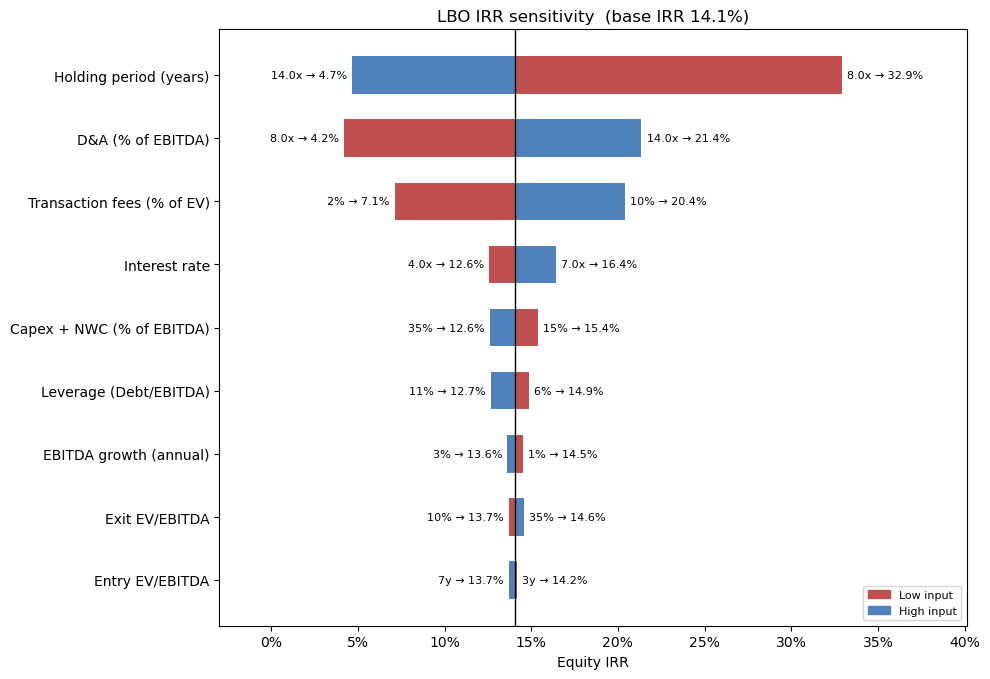

In [5]:
def fmt_input(var, v):
    if var in ("interest_rate", "ebitda_growth", "capex_nwc_pct", "fee_pct", "da_pct"):
        return f"{v:.0%}"
    if var == "holding_years":
        return f"{int(v)}y"
    return f"{v:.1f}x"

def plot_tornado(tt, base_irr, title="LBO IRR sensitivity", ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 0.6 * len(tt) + 1.5))
    for i, r in tt.iterrows():
        for irr, inp, color in ((r.irr_at_low, r.low_input, "#c0504d"),
                                (r.irr_at_high, r.high_input, "#4f81bd")):
            ax.barh(i, irr - base_irr, left=base_irr, color=color, height=0.6)
            right = irr >= base_irr
            ax.text(irr + (0.003 if right else -0.003), i,
                    f"{fmt_input(r.variable, inp)} → {irr:.1%}",
                    va="center", ha="left" if right else "right", fontsize=8)
    ax.axvline(base_irr, color="black", lw=1)
    ax.set_yticks(range(len(tt)))
    ax.set_yticklabels([LABELS[v] for v in tt.variable])
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
    ax.set_xlabel("Equity IRR")
    ax.set_title(f"{title}  (base IRR {base_irr:.1%})")
    lo = tt[["irr_at_low", "irr_at_high"]].min().min()
    hi = tt[["irr_at_low", "irr_at_high"]].max().max()
    pad = (hi - lo) * 0.25
    ax.set_xlim(lo - pad, hi + pad)
    ax.legend(handles=[Patch(color="#c0504d", label="Low input"),
                       Patch(color="#4f81bd", label="High input")],
              loc="lower right", fontsize=8)
    plt.tight_layout()
    return ax

plot_tornado(tt, base_irr)
plt.show()

In [8]:
import glob

def read_pitchbook(path):
    """Skip PitchBook's title block: find the row containing 'Deal ID' and use it as the header."""
    raw = pd.read_excel(path, header=None)
    header_row = raw.index[raw.apply(lambda r: r.astype(str).str.strip().eq("Deal ID").any(), axis=1)][0]
    df = pd.read_excel(path, header=header_row)
    df.columns = df.columns.astype(str).str.strip()
    df = df.loc[:, ~df.columns.str.startswith("Unnamed")]  # drop empty spacer columns
    return df[df["Deal ID"].notna()]                        # drop footer rows

files = sorted(glob.glob("data/*.xls*"))
merged = pd.concat([read_pitchbook(f) for f in files], ignore_index=True).drop_duplicates("Deal ID")
merged.to_csv("data/lbo_merged.csv", index=False)

print(f"{len(files)} file(s), {len(merged)} deals")
print(merged.columns.tolist())

1 file(s), 11 deals
['Deal ID', 'Companies', 'Native Currency of Deal', '% Acquired', 'Post Valuation', 'Deal Size Status', 'Deal Size', 'Deal Type', 'Deal Date', 'Company ID', 'View Company Online']


entry_multiple    0
leverage          0
da_pct            0


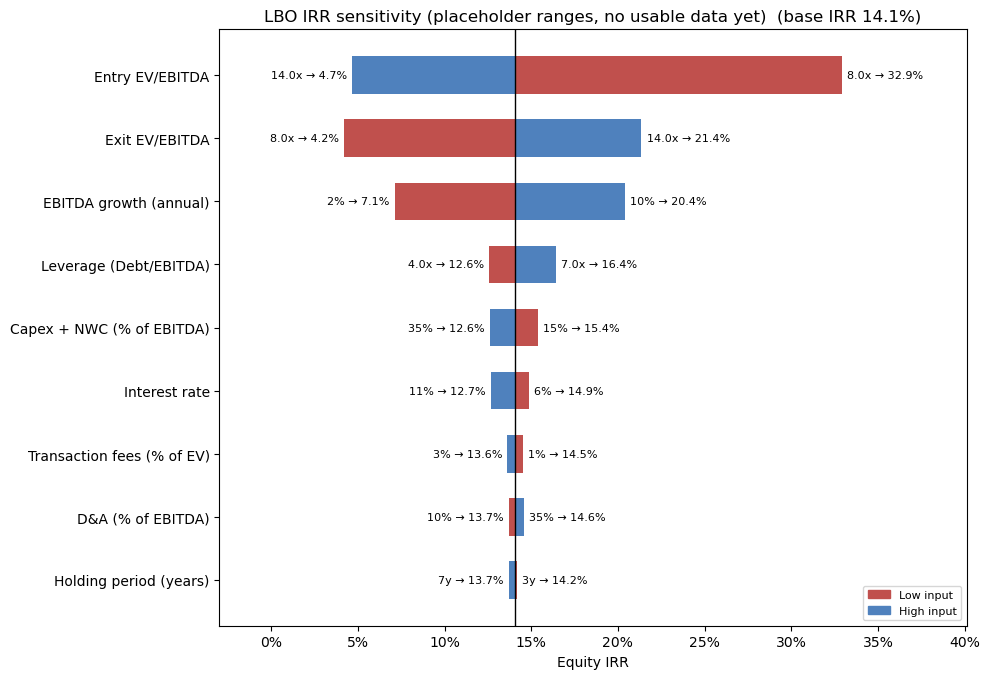

In [10]:
deals = pd.read_csv("data/lbo_merged.csv", parse_dates=["Deal Date"])
def num(col):
    return pd.to_numeric(deals[col], errors="coerce") if col in deals.columns else pd.Series(np.nan, index=deals.index)

ebitda = num("EBITDA").where(num("EBITDA") > 0)  # ratios on negative EBITDA are meaningless

inputs = pd.DataFrame({
    # Model inputs, with fallbacks when the preferred column is blank
    "entry_multiple": num("Implied EV/EBITDA")
                        .fillna(num("Valuation/EBITDA"))
                        .fillna(num("Deal Size/EBITDA"))
                        .fillna(num("Implied EV") / ebitda),
    "leverage":       num("Debt/EBITDA")
                        .fillna(num("Debt Raised in Round") / ebitda)
                        .fillna(num("Total Debt (from financials)") / ebitda),
    "da_pct":         (ebitda - num("EBIT")) / ebitda,
    # Sanity checks and descriptors
    "equity_pct":     num("Total Invested Equity") / num("Implied EV"),
    "ebitda_margin":  ebitda / num("Revenue"),
    "ev":             num("Implied EV").fillna(num("Deal Size")),
    # Segments
    "sector":         deals.get("Primary PitchBook Industry Sector"),
    "region":         deals.get("HQ Global Region"),
    "year":           deals["Deal Date"].dt.year,
})

BOUNDS = {"entry_multiple": (2, 40), "leverage": (0, 12), "da_pct": (0, 0.8)}
for var, (lo, hi) in BOUNDS.items():
    inputs.loc[~inputs[var].between(lo, hi), var] = np.nan  # drop implausible values

# How many deals have each input?
print(inputs[list(BOUNDS)].notna().sum().to_string())

def ranges_from_inputs(inp, vars_=tuple(BOUNDS)):
    out = {}
    for v in vars_:
        s = inp[v].dropna()
        if len(s) >= 30:  # skip inputs with too few observations to trust
            p10, p50, p90 = s.quantile([0.10, 0.50, 0.90])
            out[v] = {"n": len(s), "p10": p10, "p50": p50, "p90": p90}
    return pd.DataFrame(out).T

def data_driven_tornado(inp, title):
    st = ranges_from_inputs(inp)
    b, r = dict(base), dict(ranges)
    for v in st.index:
        b[v] = st.loc[v, "p50"]
        r[v] = (st.loc[v, "p10"], st.loc[v, "p90"])
    b["exit_multiple"], r["exit_multiple"] = b["entry_multiple"], r["entry_multiple"]
    t, bi = tornado_table(b, r)
    return st, t, bi

source = "PitchBook ranges" if not stats.empty else "placeholder ranges, no usable data yet"
plot_tornado(tt, base_irr, title=f"LBO IRR sensitivity ({source})")
plt.show()